In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import warnings
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
warnings.filterwarnings('ignore')

In [103]:
plt.rcParams['figure.figsize'] = (10,8)
plt.rcParams['figure.dpi'] = 100 
plt.rcParams['font.size'] = 14 

In [104]:
df = pd.read_csv('SampleData\SampleData\HomePrices.csv')

In [105]:
# x = df[['Area']] 
# # R-squared:                     0.938, Adj. R-squared:                  0.934
# x = df[['Age']] 
# #R-squared:                      0.167, Adj. R-squared:                  0.118
# x = df[['Bedrooms']] 
# R-squared:                       0.827, Adj. R-squared:                  0.816
# x = df[['Area','Bedrooms']]
# R-squared:                       0.938, Adj. R-squared:                  0.930
# x = df[['Area','Age']]
# R-squared:                       0.946, Adj. R-squared:                  0.939
x = df[['Age','Bedrooms']]
# R-squared:                       0.859, Adj. R-squared:                  0.841
# x = df[['Area','Age','Bedrooms']]
# R-squared:                       0.946, Adj. R-squared:                  0.935


y = df['Price']
x, y = np.array(x), np.array(y)
x =    sm.add_constant(x)

In [106]:
# plt.scatter(df.Price, df.Area)
# plt.xlabel('Price')
# plt.ylabel('Area')
# plt.show()

In [107]:
# corr = df.corr()
# plt.matshow(corr) 

# for (a,b) , value in np.ndenumerate(corr):
#     plt.text(b,a,f'{value:.2f}',ha='center',va='center', fontdict= {'color': 'gray'})

# plt.xticks(range(len(corr.columns)), corr.columns.values)
# plt.yticks(range(len(corr.columns)), corr.columns.values)
# plt.show()

<Axes: >

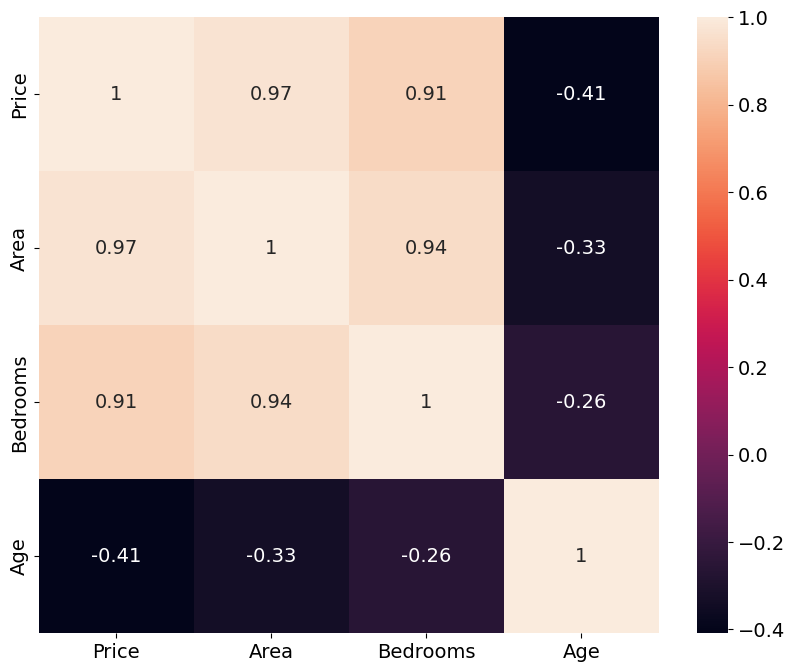

In [108]:
corr = df . corr() 
sns.heatmap(corr, xticklabels=corr.columns.values, yticklabels=corr.columns.values, annot=True)

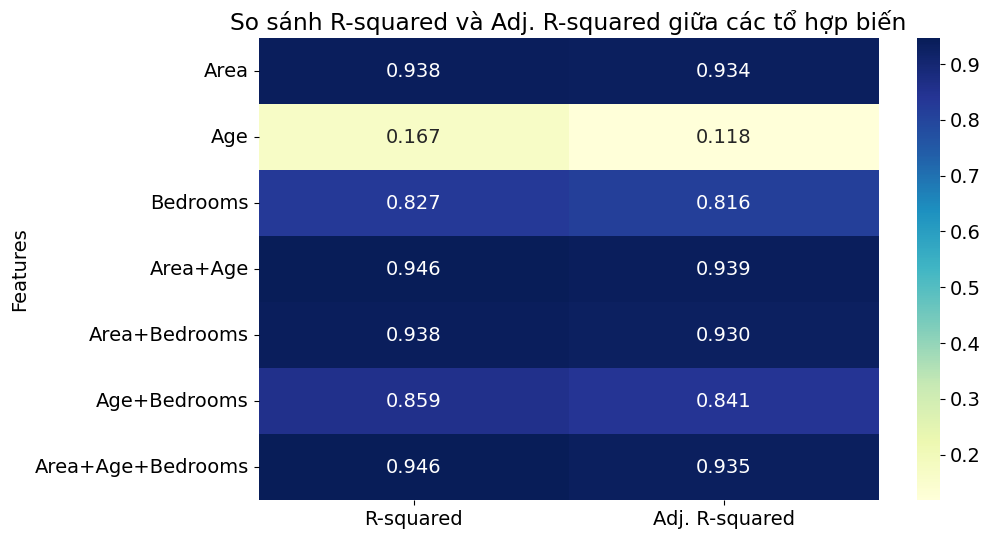

In [109]:
from itertools import combinations

# Danh sách các biến độc lập
features = ['Area', 'Age', 'Bedrooms']
results_list = []

# Chạy vòng lặp cho các tổ hợp từ 1 đến n biến
for r in range(1, len(features) + 1):
    for combo in combinations(features, r):
        X = df[list(combo)]
        X = sm.add_constant(X) # Thêm hằng số intercept
        model = sm.OLS(y, X).fit()
        
        results_list.append({
            'Features': "+".join(combo),
            'R-squared': model.rsquared,
            'Adj. R-squared': model.rsquared_adj
        })

# Tạo DataFrame kết quả
df_res = pd.DataFrame(results_list).set_index('Features')

# Vẽ Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_res, annot=True, cmap='YlGnBu', fmt=".3f")
plt.title('So sánh R-squared và Adj. R-squared giữa các tổ hợp biến')
plt.show()

## Thư viện Stepwwhy ?? sẽ hổ trợ việc này, vì số trường hợp đang là n bình - 1.

In [ ]:
# R_sq = results.rsquared
# params = results.params

In [111]:
# # predict
# predicted_values = results.predict(x)
# plt.plot(df["Price"], label="Actual")
# plt.plot(predicted_values, label="Predicted",color='red',marker='x',linestyle='--')
# plt.ylabel("Home_Price")
# plt.legend()
# plt.grid(True)

# plt.show()